In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import math
from matplotlib import ticker
import scipy.linalg as la
%matplotlib widget

# Effective Low-energy Hamiltonian for a pair of MZMs at the ends of a nanowire

$$
H = \delta c^\dagger c + \delta_{QD} d^\dagger d + \sqrt{2}t_Re^{i\pi\phi}\left(\gamma_R + \zeta_R\gamma_L\right)d + \dfrac{1}{\sqrt{2}}t_Ld\left(\gamma_L + \zeta_L\gamma_R\right) + \text{h.c.}
$$

where $t_{L,R} \gt 0$ are hopping amplitudes through left and right ends of the wire, $\zeta_{L,R}$ are the leakage amplitudes of the MZMs across the wire and $\delta$ is the MZM splitting. Writing the entire Hamiltonian in terms of the fermion operator $c = \dfrac{1}{\sqrt{2}}\left(\hat{\gamma_R} + i\hat{\gamma_L} \right)$,

$$
H = \delta c^\dagger c + \delta_{QD} d^\dagger d + d\left[t_Re^{i\pi\phi}\{(1 + i\zeta_R)c^\dagger + (1 - i\zeta_R)c\} + t_L\{(i + \zeta_L)c^\dagger + (-i + \zeta_l)c \}\right] + \text{h.c.}
$$ 

Separating the Hamiltonian in terms of two separate fermion parity-

1. Even fermion parity sector $c^\dagger c + d^\dagger d = 0,2$ then $cd^\dagger = c^\dagger d = 0$ enabling us to write $d^\dagger d = c^\dagger c = (1 + \nu_z)/2$ and $c^\dagger d^\dagger = \nu_+$. We get,

$$
H_{even}(\phi) = \dfrac{1}{2}\left(\delta+\delta_{QD}\right) + \dfrac{1}{2}\left(\delta+\delta_{QD}\right)\nu_z + \{t_Re^{i\pi\phi}(1 - i\zeta_R) + t_L(-i+\zeta_L)\}\nu_- + \text{h.c.}
$$ 

2. Odd fermion parity sector $c^\dagger c + d^\dagger d = 1$ then $c^\dagger d^\dagger = cd = 0$ enabling us to write $1 - d^\dagger d = c^\dagger c = (1 + \nu_z)/2$ and $dc^\dagger = \nu_+$. We get,

$$
H_{odd}(\phi) = \dfrac{1}{2}\left(\delta+\delta_{QD}\right) + \dfrac{1}{2}\left(\delta-\delta_{QD}\right)\nu_z + \{t_Re^{i\pi\phi}(1 + i\zeta_R) + t_L(i+\zeta_L)\}\nu_+ + \text{h.c.}
$$

The Hamiltonian in each case can be written as $H = \dfrac{1}{2}\left(\delta+\delta_{QD}\right) + \dfrac{1}{2}(\delta\pm\delta_{QD})\nu_z + A\nu_+ + A^*\nu_-$ ($+$ for even parity and $-$ for odd). Which lets us compute the energy eigenvalues as follows,

$$
\epsilon = \dfrac{\delta+\delta_{QD}}{2}\pm \left\{ 
    \begin{array}{ll}
    \sqrt{\dfrac{(\delta+\delta_{QD})^2}{4} + |A|^2} & \text{for even parity} \\
    \sqrt{\dfrac{(\delta-\delta_{QD})^2}{4} + |A|^2} & \text{for odd parity}
\end{array} \right.
$$

where,

$$
|A|^2 = \left\{ 
    \begin{array}{ll}
    |t_Re^{i\pi\phi}(1 - i\zeta_R) + t_L(-i+\zeta_L)|^2 & \text{for even parity} \\
    |t_Re^{i\pi\phi}(1 + i\zeta_R) + t_L(i+\zeta_L)|^2 & \text{for odd parity}
\end{array} \right.
$$

The expression for $|A|^2$ can be simplified into the form of a function $f(\phi) = P + Q\cos{\pi\phi} + R\sin{\pi\phi}$ as follows,

$$
P = \left\{
    \begin{array}{ll}
    t_R^2\left(x_R^2 + y_R^2 + 2y_R + 1\right) + t_L^2\left(x_L^2 + y_L^2 - 2y_L + 1\right) & \text{for even parity}\\
    t_R^2\left(x_R^2 + y_R^2 - 2y_R + 1\right) + t_L^2\left(x_L^2 + y_L^2 + 2y_L + 1\right) & \text{for odd parity}
    \end{array} \right.
$$
$$
Q = \left\{
    \begin{array}{ll}
    2t_Lt_R\left(x_l + x_R + x_Ly_R - x_Ry_L\right) & \text{for even parity}\\
    2t_Lt_R\left(x_l + x_R - x_Ly_R + x_Ry_L\right) & \text{for odd parity}
    \end{array} \right.
$$
$$
R = \left\{
    \begin{array}{ll}
    2t_Lt_R\left(y_L - y_R - 1 + x_Lx_R + y_Ly_R\right) & \text{for even parity}\\
    2t_Lt_R\left(y_L - y_R + 1 - x_Lx_R - y_Ly_R\right) & \text{for odd parity}
    \end{array} \right.
$$

where $\zeta_{L/R} = x_{L/R} + iy_{L/R}$

Going forward with the positive energies allows us to easily compute current ($\propto \dfrac{\partial \epsilon}{\partial \phi}$),

$$
I = \dfrac{\partial \epsilon}{\partial \phi} = \left\{
    \begin{array}{ll}
    \dfrac{1}{2\sqrt{\dfrac{(\delta+\delta_{QD})^2}{4} + f(\phi)}}\dfrac{\partial f}{\partial \phi} & \text{for even parity} \\
    \dfrac{1}{2\sqrt{\dfrac{(\delta-\delta_{QD})^2}{4} + f(\phi)}}\dfrac{\partial f}{\partial \phi} & \text{for odd parity}
    \end{array} \right.
$$

inductance ($\propto \dfrac{\partial^2 \epsilon}{\partial \phi^2}$),

$$
L = \dfrac{\partial^2 \epsilon}{\partial \phi^2} = \left\{
    \begin{array}{ll}
    \dfrac{1}{2\sqrt{\dfrac{(\delta+\delta_{QD})^2}{4} + f(\phi)}}\dfrac{\partial^2 f}{\partial \phi^2} - \dfrac{1}{4\left(\dfrac{(\delta+\delta_{QD})^2}{4} + f(\phi) \right)^{3/2}}\left(\dfrac{\partial f}{\partial \phi}\right)^2 & \text{for even parity} \\
    \dfrac{1}{2\sqrt{\dfrac{(\delta-\delta_{QD})^2}{4} + f(\phi)}}\dfrac{\partial^2 f}{\partial \phi^2} - \dfrac{1}{4\left(\dfrac{(\delta-\delta_{QD})^2}{4} + f(\phi) \right)^{3/2}}\left(\dfrac{\partial f}{\partial \phi}\right)^2 & \text{for odd parity}
    \end{array} \right.
$$

and capacitance values ($\propto \dfrac{\partial^2 \epsilon}{\partial \delta_{QD}^2}$),

$$
C = \dfrac{\partial^2 \epsilon}{\partial \delta_{QD}^2} = \left\{
    \begin{array}{ll}
    \dfrac{|A|^2}{4\left[\dfrac{(\delta+\delta_{QD})^2}{4} + |A|^2\right]^{3/2}} & \text{for even parity} \\
    \dfrac{|A|^2}{4\left[\dfrac{(\delta-\delta_{QD})^2}{4} + |A|^2\right]^{3/2}} & \text{for odd parity}
    \end{array} \right.
$$

On further simplification (for $\zeta_{L/R}$ being real) $|A|^2$ can be written in the form of a simpler $f(\phi) = P + Q\cos{\pi\phi} + R\sin{\pi\phi}$ where P, Q and R are as follows,

$$P = t_L^2(1 + \zeta_L^2) + t_R^2(1 + \zeta_R^2) \\
$$
$$
Q = 2t_Lt_R(\zeta_L + \zeta_R)
$$
$$
R = \left\{
    \begin{array}{ll}
    2t_Lt_R(\zeta_L\zeta_R - 1) & \text{for even parity}\\
    2t_Lt_R(1 - \zeta_L\zeta_R) & \text{for odd parity}
    \end{array} \right.
$$

For a truly topological state $\delta=\zeta_L=\zeta_R=0$ (and $\delta_{QD}$ not playing a part in the energy by being at a considerably higher energy level) making the expression for current to be,

$$
I \propto \dfrac{\partial \epsilon}{\partial \phi} = \left\{
    \begin{array}{ll}
    \dfrac{-\pi t_Lt_R\cos(\pi\phi)}{\sqrt{t_L^2 + t_R^2 - 2t_Lt_R\sin(\pi\phi)}} & \text{for even parity} \\
    \dfrac{\pi t_Lt_R\cos(\pi\phi)}{\sqrt{t_L^2 + t_R^2 + 2t_Lt_R\sin(\pi\phi)}} & \text{for odd parity} 
    \end{array} \right.
$$

and the inductance term being,

$$
L \propto \dfrac{\partial^2 \epsilon}{\partial \phi^2} = \left\{
    \begin{array}{ll}
    \dfrac{\pi^2 t_Lt_R\left[(t_L^2 + t_R^2)\sin(\pi\phi) - t_Lt_R(1 + \sin^2(\pi\phi))\right]}{\left(t_L^2 + t_R^2 - 2t_Lt_R\sin(\pi\phi)\right)^\dfrac{3}{2}} & \text{for even parity} \\
    \dfrac{-\pi^2 t_Lt_R\left[(t_L^2 + t_R^2)\sin(\pi\phi) + t_Lt_R(1 + \sin^2(\pi\phi))\right]}{\left(t_L^2 + t_R^2 + 2t_Lt_R\sin(\pi\phi)\right)^\dfrac{3}{2}} & \text{for odd parity} 
    \end{array} \right.
$$

In [4]:
#True topological Parameters
delta = 0.0
delta_QD = 2.0
t_R, t_L = 0.2, 0.2
zeta_L, zeta_R = 0.00, 0.00
phi0 = np.linspace(0.0,2.0,3000)

def m1_P(parity="even"):
    x_r, y_r = zeta_R.real, zeta_R.imag
    x_l, y_l = zeta_L.real, zeta_L.imag
    if parity=="odd":
        return t_R**2.0 * (x_r**2.0 + y_r**2.0 - 2*y_r + 1) + t_L**2.0 * (x_l**2.0 + y_l**2.0 + 2*y_l + 1)
    return t_R**2.0 * (x_r**2.0 + y_r**2.0 + 2*y_r + 1) + t_L**2.0 * (x_l**2.0 + y_l**2.0 - 2*y_l + 1)

def m1_Q(parity="even"):
    x_r, y_r = zeta_R.real, zeta_R.imag
    x_l, y_l = zeta_L.real, zeta_L.imag
    if parity=="odd":
        return 2.0 * t_R * t_L * (x_r + x_l - x_l*y_r + x_r*y_l)
    return 2.0 * t_R * t_L * (x_r + x_l + x_l*y_r - x_r*y_l)

def m1_R(parity="even"):
    x_r, y_r = zeta_R.real, zeta_R.imag
    x_l, y_l = zeta_L.real, zeta_L.imag
    if parity=="odd":
        return 2.0 * t_R * t_L * (y_l - y_r + 1 - x_r*x_l - y_r*y_l)
    return 2.0 * t_R * t_L * (y_l - y_r - 1 + x_r*x_l + y_r*y_l)

def m1_modA2(parity="even", phi=phi0):
    return m1_P(parity) + m1_Q(parity) * np.cos(np.pi*phi) + m1_R(parity) * np.sin(np.pi*phi)

def m1_dfdphi(parity="even", phi=phi0):
    return -np.pi * m1_Q(parity) * np.sin(np.pi*phi) + np.pi * m1_R(parity) * np.cos(np.pi*phi)

def m1_d2fdphi2(parity="even", phi=phi0):
    return -np.pi**2 * m1_Q(parity) * np.cos(np.pi*phi) - np.pi**2 * m1_R(parity) * np.sin(np.pi*phi)

def m1_neg_energy(parity="even", phi=phi0):
    delta_net = 0.0
    if parity=="odd":
        delta_net = (delta - delta_QD)/2.0
    else:
        delta_net = (delta + delta_QD)/2.0
    return (delta+delta_QD)/2.0 - np.sqrt((delta_net)**2 + m1_modA2(parity=parity, phi=phi))

def m1_pos_energy(parity="even", phi=phi0):
    delta_net = 0.0
    if parity=="odd":
        delta_net = (delta - delta_QD)/2.0
    else:
        delta_net = (delta + delta_QD)/2.0
    return (delta+delta_QD)/2.0 + np.sqrt((delta_net)**2 + m1_modA2(parity=parity, phi=phi))

def m1_current(parity="even", phi=phi0):
    delta_net = 0.0
    if parity=="odd":
        delta_net = (delta - delta_QD)/2.0
    else:
        delta_net = (delta + delta_QD)/2.0
    return (1.0/(2.0)) * (m1_dfdphi(parity=parity, phi=phi) / np.sqrt((delta_net)**2 + m1_modA2(parity=parity, phi=phi)))

def m1_inductance(parity="even", phi=phi0):
    delta_net = 0.0
    if parity=="odd":
        delta_net = (delta - delta_QD)/2.0
    else:
        delta_net = (delta + delta_QD)/2.0
    term1 = -(1.0/4.0) * (m1_dfdphi(parity=parity, phi=phi)**2.0) / ((delta_net)**2 + m1_modA2(parity=parity, phi=phi))**(3.0/2.0)
    term2 = (1.0/2.0) * (m1_d2fdphi2(parity=parity, phi=phi)) / np.sqrt((delta_net)**2 + m1_modA2(parity=parity, phi=phi))
    return term1 + term2

def m1_capacitance(parity="even", phi=phi0):
    delta_net = 0.0
    if parity=="odd":
        delta_net = (delta - delta_QD)/2.0
    else:
        delta_net = (delta + delta_QD)/2.0
    return m1_modA2(parity=parity, phi=phi) / (4.0 * ((delta_net)**2 + m1_modA2(parity=parity, phi=phi))**(3.0/2.0))

def m1_cap_wo_qd(parity="even", phi=phi0):
    return 2*m1_modA2(parity=parity, phi=phi) / (delta**2.0 + 4.0*m1_modA2(parity=parity, phi=phi))**(3.0/2.0)

In [7]:

# --- Interactive plot ---
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as ticker
from ipywidgets import FloatSlider, HBox, VBox, interactive_output, Layout, Output

# Sliders in two rows
s_delta       = FloatSlider(description="delta",     value=float(globals().get('delta', 0.0)),   min=0.00, max=1.00,  step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_delta_QD    = FloatSlider(description="delta_QD",  value=float(globals().get('delta_QD', 2.0)),min=0.00, max=10.00, step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_tL          = FloatSlider(description="t_L",       value=float(globals().get('t_L', 1.0)),     min=0.00, max=1.00,  step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_tR          = FloatSlider(description="t_R",       value=float(globals().get('t_R', 1.0)),     min=0.00, max=1.00,  step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_zeta_re_l   = FloatSlider(description="Re ζ (L)",  value=float(np.real(globals().get('zeta_L', 0.0))), min=0.0, max=1.0, step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_zeta_im_l   = FloatSlider(description="Im ζ (L)",  value=float(np.imag(globals().get('zeta_L', 0.0))), min=0.0, max=1.0, step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_zeta_re_r   = FloatSlider(description="Re ζ (R)",  value=float(np.real(globals().get('zeta_R', 0.0))), min=0.0, max=1.0, step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_zeta_im_r   = FloatSlider(description="Im ζ (R)",  value=float(np.real(globals().get('zeta_R', 0.0))), min=0.0, max=1.0, step=0.01, readout_format=".2f", layout=Layout(width="300px"))

row1 = HBox([s_delta, s_delta_QD, s_tL, s_tR], layout=Layout(justify_content="center", gap="12px"))
row2 = HBox([s_zeta_re_l, s_zeta_im_l, s_zeta_re_r, s_zeta_im_r], layout=Layout(justify_content="center", gap="12px"))

# Prepare figure
plt.ioff()
plt.close('all')                
fig = plt.figure(figsize=(10, 6))
from matplotlib.gridspec import GridSpec
gs = GridSpec(2,2, figure=fig, hspace=0.15, wspace=0.4)

ax3 = fig.add_subplot(gs[0, 0])  # Energy vs Phase (top-left)
ax4 = fig.add_subplot(gs[0, 1])  # Capacitance vs Phase (top-right)
ax1 = fig.add_subplot(gs[1, 0])  # Current vs Phase (bottom-left)
ax2 = fig.add_subplot(gs[1, 1])  # Inductance vs Phase (bottom-right)

for ax in [ax1, ax2, ax3, ax4]:
    ax.grid(True)

# Pre-create artists
(ln_E_neg_e,) = ax3.plot([], [], ".", label="Even Parity", color='blue')
(ln_E_neg_o,) = ax3.plot([], [], ".", label="Odd Parity",  color='red')
(ln_E_pos_e,) = ax3.plot([], [], ".", color='blue')
(ln_E_pos_o,) = ax3.plot([], [], ".", color='red')
ax3.set_title("Energy vs Phase"); ax3.set_ylabel("Energy"); ax3.xaxis.set_major_formatter(ticker.NullFormatter())
ax3.legend(bbox_to_anchor=(0.5, 1), loc='upper left')

(ln_C_e,) = ax4.plot([], [], ".", label="Even Parity", color='blue')
(ln_C_o,) = ax4.plot([], [], ".", label="Odd Parity",  color='red')
ax4.set_title("Capacitance vs Phase"); ax4.set_ylabel("Capacitance"); ax4.xaxis.set_major_formatter(ticker.NullFormatter())

(ln_I_e,) = ax1.plot([], [], ".", label="Even Parity", color='blue')
(ln_I_o,) = ax1.plot([], [], ".", label="Odd Parity",  color='red')
ax1.set_title("Current vs Phase"); ax1.set_xlabel("Phase (in units of $2\\phi_0$)"); ax1.set_ylabel("Current")

(ln_L_e,) = ax2.plot([], [], ".", label="Even Parity", color='blue')
(ln_L_o,) = ax2.plot([], [], ".", label="Odd Parity",  color='red')
ax2.set_title("Inductance vs Phase"); ax2.set_xlabel("Phase (in units of $2\\phi_0$)"); ax2.set_ylabel("Inductance")

phi = np.linspace(0.0, 2.0, 3000)

def update(delta, delta_QD, tL, tR, zeta_re_l, zeta_im_l, zeta_re_r, zeta_im_r):
    # Synchronize globals
    global t_L, t_R, zeta_L, zeta_R
    t_L = float(tL); t_R = float(tR)
    zeta_L = complex(zeta_re_l, zeta_im_l)
    zeta_R = complex(zeta_re_r, zeta_im_r)
    globals()['delta'] = float(delta)
    globals()['delta_QD'] = float(delta_QD)

    try:
        I_even = m1_current(phi=phi, parity="even");  I_odd  = m1_current(phi=phi, parity="odd")
    except Exception as e:
        I_even = I_odd = np.zeros_like(phi); ax1.set_title(f"Current vs Phase (err: {e})")
    try:
        L_even = m1_inductance(phi=phi, parity="even"); L_odd  = m1_inductance(phi=phi, parity="odd")
    except Exception as e:
        L_even = L_odd = np.zeros_like(phi); ax2.set_title(f"Inductance vs Phase (err: {e})")
    try:
        Eneg_e = m1_neg_energy(phi=phi, parity="even"); Eneg_o = m1_neg_energy(phi=phi, parity="odd")
        Epos_e = m1_pos_energy(phi=phi, parity="even"); Epos_o = m1_pos_energy(phi=phi, parity="odd")
    except Exception as e:
        Eneg_e = Eneg_o = Epos_e = Epos_o = np.zeros_like(phi); ax3.set_title(f"Energy vs Phase (err: {e})")
    try:
        # Use special "no QD" capacitance when delta_QD≈0, else general capacitance
        if abs(delta_QD) < 1e-12 and 'cap_wo_qd' in globals():
            C_even = m1_cap_wo_qd(phi=phi, parity="even"); C_odd  = m1_cap_wo_qd(phi=phi, parity="odd")
            ax4.set_title("Capacitance vs Phase (No QD)")
        else:
            C_even = m1_capacitance(phi=phi, parity="even"); C_odd  = m1_capacitance(phi=phi, parity="odd")
            ax4.set_title("Capacitance vs Phase")
    except Exception as e:
        C_even = C_odd = np.zeros_like(phi); ax4.set_title(f"Capacitance vs Phase (err: {e})")

    # Update artists and autoscale per panel
    ln_I_e.set_data(phi, I_even); ln_I_o.set_data(phi, I_odd)
    ln_L_e.set_data(phi, L_even); ln_L_o.set_data(phi, L_odd)
    for ax, y1, y2 in [(ax1, I_even, I_odd), (ax2, L_even, L_odd)]:
        ax.set_xlim(phi.min(), phi.max())
        ymin, ymax = np.nanmin([y1.min(), y2.min()]), np.nanmax([y1.max(), y2.max()])
        pad = 0.05*(ymax - ymin + 1e-12); ax.set_ylim(ymin - pad, ymax + pad)

    ln_E_neg_e.set_data(phi, Eneg_e); ln_E_neg_o.set_data(phi, Eneg_o)
    ln_E_pos_e.set_data(phi, Epos_e); ln_E_pos_o.set_data(phi, Epos_o)
    ax3.set_xlim(phi.min(), phi.max())
    ymin = np.nanmin([Eneg_e.min(), Eneg_o.min(), Epos_e.min(), Epos_o.min()])
    ymax = np.nanmax([Eneg_e.max(), Eneg_o.max(), Epos_e.max(), Epos_o.max()])
    pad = 0.05*(ymax - ymin + 1e-12); ax3.set_ylim(ymin - pad, ymax + pad)

    ln_C_e.set_data(phi, C_even); ln_C_o.set_data(phi, C_odd)
    ax4.set_xlim(phi.min(), phi.max())
    ymin, ymax = np.nanmin([C_even.min(), C_odd.min()]), np.nanmax([C_even.max(), C_odd.max()])
    pad = 0.05*(ymax - ymin + 1e-12); ax4.set_ylim(ymin - pad, ymax + pad)

    fig.canvas.draw_idle()

_fig_out = Output()
with _fig_out:
    display(fig.canvas)

out = interactive_output(update, {"delta": s_delta, "delta_QD": s_delta_QD, "tL": s_tL, "tR": s_tR, "zeta_re_l": s_zeta_re_l, "zeta_im_l": s_zeta_im_l, "zeta_re_r": s_zeta_re_r, "zeta_im_r": s_zeta_im_r})
display(VBox([_fig_out, row1, row2, out]))

# Initialize
update(s_delta.value, s_delta_QD.value, s_tL.value, s_tR.value, s_zeta_re_l.value, s_zeta_im_l.value, s_zeta_re_r.value, s_zeta_im_r.value)


# Effective Low-energy Hamiltonian for a pair of q-MZMs at both the ends of a nanowire

In the limit the dot-level is detuned far from the fermi energy level $\epsilon_d \gg A_s, B_s$,

$$
H \approx \Sigma_{s=\{L,R\}} \epsilon_s c_s^\dagger c_s - \epsilon_d^{-1}\left[(A_L c_L^\dagger + B_L c_Le^{i\pi\phi})(B_R c_R^\dagger + A_R c_R) + h.c \right]
$$

Separating the Hamiltonian in terms of two separate fermion parity and expressing in terms of Pauli matrices-

1. Even fermion parity sector $c_L^\dagger c_L + c_R^\dagger c_R = 0,2$ then $c_Lc_R^\dagger = c_L^\dagger c_R = 0$ enabling us to write $c_L^\dagger c_L = c_R^\dagger c_R = (1 - \nu_z)/2$ and $c_s^\dagger c_s^\dagger = \nu_-$. We get,

$$
H \approx \Sigma_{s=\{L,R\}} \dfrac{\epsilon_s}{2} (1-\sigma_z) - \epsilon_d^{-1}\left[(A_L B_R + e^{-i\pi\phi}A_R^*B_L^*)\nu_{-} + (A_L^*B_R^* + e^{i\pi\phi}A_RB_L)\nu_{+} \right]
$$ 

2. Odd fermion parity sector $c_L^\dagger c_L + c_R^\dagger c_R = 1$ then $c_L^\dagger c_R^\dagger = c_Lc_R = 0$ enabling us to write $1 - c_R^\dagger c_R = c_L^\dagger c_L = (1 - \nu_z)/2$ and $c_R^\dagger c_L = c_Lc_R^\dagger = \nu_+$. We get,

$$
H \approx \Sigma_{s=\{L,R\}} \dfrac{\epsilon_s}{2} (1\pm\sigma_z) - \epsilon_d^{-1}\left[(A_L A_R + e^{-i\pi\phi}B_R^*B_L^*)\nu_{-} + (A_L^*A_R^* + e^{i\pi\phi}B_RB_L)\nu_{+} \right]
$$

($+$ in case of s=R and $-$ for s=L)

The Hamiltonian in each case can be written as $H = \dfrac{1}{2}\left(\epsilon_L+\epsilon_R\right) - \dfrac{1}{2}(\epsilon_L + (-1)^P \epsilon_R)\nu_z - \dfrac{1}{\epsilon_d}\left[A\nu_+ + A^*\nu_-\right]$ ($P=0$ for even parity and $P=1$ for odd). Which lets us compute the energy eigenvalues as follows,

$$
\epsilon = \dfrac{\epsilon_L+\epsilon_R}{2} \pm \left\{ 
    \begin{array}{ll}
    \sqrt{\dfrac{(\epsilon_L+\epsilon_R)^2}{4} + \dfrac{|A_p|^2}{\epsilon_d^2}} & \text{for even parity} \\
    \sqrt{\dfrac{(\epsilon_L-\epsilon_R)^2}{4} + \dfrac{|A_p|^2}{\epsilon_d^2}} & \text{for odd parity}
\end{array} \right.
$$

where,

$$
|A_p|^2 = \left\{ 
    \begin{array}{ll}
    |A_RB_Le^{i\pi\phi} + A_L^*B_R^*|^2 & \text{for even parity} \\
    |B_RB_Le^{i\pi\phi} + A_L^*A_R^*|^2 & \text{for odd parity}
\end{array} \right.
$$

Going forward with the positive energies allows us to easily compute current ($\propto \dfrac{\partial \epsilon}{\partial \phi}$),

$$
I = \dfrac{\partial \epsilon}{\partial \phi} = \left\{
    \begin{array}{ll}
    \dfrac{1}{2\epsilon_d^2\sqrt{\dfrac{(\epsilon_L+\epsilon_R)^2}{4} + \dfrac{f(\phi)}{\epsilon_d^2}}}\dfrac{\partial f}{\partial \phi} & \text{for even parity} \\
    \dfrac{1}{2\epsilon_d^2\sqrt{\dfrac{(\epsilon_L-\epsilon_R)^2}{4} + \dfrac{f(\phi)}{\epsilon_d^2}}}\dfrac{\partial f}{\partial \phi} & \text{for odd parity}
    \end{array} \right.
$$

inductance ($\propto \dfrac{\partial^2 \epsilon}{\partial \phi^2}$),

$$
L = \dfrac{\partial^2 \epsilon}{\partial \phi^2} = \left\{
    \begin{array}{ll}
    \dfrac{1}{2\epsilon_d^2\sqrt{\dfrac{(\epsilon_L+\epsilon_R)^2}{4} + \dfrac{f(\phi)}{\epsilon_d^2}}}\dfrac{\partial^2 f}{\partial \phi^2} - \dfrac{1}{4\epsilon_d^4\left(\dfrac{(\epsilon_L+\epsilon_R)^2}{4} + \dfrac{f(\phi)}{\epsilon_d^2} \right)^{3/2}}\left(\dfrac{\partial f}{\partial \phi}\right)^2 & \text{for even parity} \\
    \dfrac{1}{2\epsilon_d^2\sqrt{\dfrac{(\epsilon_L-\epsilon_R)^2}{4} + \dfrac{f(\phi)}{\epsilon_d^2}}}\dfrac{\partial^2 f}{\partial \phi^2} - \dfrac{1}{4\epsilon_d^4\left(\dfrac{(\epsilon_L-\epsilon_R)^2}{4} + \dfrac{f(\phi)}{\epsilon_d^2} \right)^{3/2}}\left(\dfrac{\partial f}{\partial \phi}\right)^2 & \text{for odd parity}
    \end{array} \right.
$$

and capacitance values ($\propto \dfrac{\partial^2 \epsilon}{\partial \delta_{QD}^2}$),

$$
C = \dfrac{\partial^2 \epsilon}{\partial \delta_{QD}^2} = \left\{
    \begin{array}{ll}
    |A_p|^2\left(\dfrac{2 + 3\epsilon_d^2(\epsilon_L+\epsilon_R)^2}{\epsilon_d^3\left[((\epsilon_L+\epsilon_R)\epsilon_d)^2 + |A_p|^2\right]^{3/2}}\right) & \text{for even parity} \\
    |A_p|^2\left(\dfrac{2 + 3\epsilon_d^2(\epsilon_L-\epsilon_R)^2}{\epsilon_d^3\left[((\epsilon_L-\epsilon_R)\epsilon_d)^2 + |A_p|^2\right]^{3/2}}\right) & \text{for odd parity}
    \end{array} \right.
$$




In [5]:
# Model Parameters
epsilon_L, epsilon_R, epsilon_D = 0.0, 0.0, 2.0
epsilon_0 = epsilon_L+epsilon_R
A_L, A_R = 0.01 + 0.0j, 0.01 + 0.0j
B_L, B_R = 0.01 + 0.0j, 0.01 + 0.0j

def m2_f(phi, parity="odd"):
    ## Returns |A_p|^2
    X_Re = (A_L*A_R*B_L*B_R).real
    X_Im = (A_L*A_R*B_L*B_R).imag
    X_0 = (abs(A_R)*abs(B_L))**2.0 + (abs(A_L)*abs(B_R))**2.0 
    if parity=="odd":
        X_0 = (abs(B_R)*abs(B_L))**2.0 + (abs(A_L)*abs(A_R))**2.0 
    return X_0 + 2.0*(X_Re*np.cos(np.pi*phi) - X_Im*np.sin(np.pi*phi))

def m2_df_dphi(phi):
    X_Re = (A_L*A_R*B_L*B_R).real
    X_Im = (A_L*A_R*B_L*B_R).imag
    return 2.0*np.pi*(-X_Re*np.sin(np.pi*phi) - X_Im*np.cos(np.pi*phi))

def m2_d2f_dphi2(phi):
    X_Re = (A_L*A_R*B_L*B_R).real
    X_Im = (A_L*A_R*B_L*B_R).imag
    return 2.0*(np.pi**2.0)*(-X_Re*np.cos(np.pi*phi) + X_Im*np.sin(np.pi*phi))

def m2_pos_energy(phi, parity="odd"):
    if parity=="odd":
        return epsilon_0 + (((epsilon_L-epsilon_R)/2.0)**2.0 + (m2_f(phi, parity)/(epsilon_D**2.0)))**0.5
    return epsilon_0 + (((epsilon_R+epsilon_L)/2.0)**2.0 + (m2_f(phi, parity)/(epsilon_D**2.0)))**0.5

def m2_neg_energy(phi, parity="odd"):
    if parity=="odd":
        return epsilon_0 - (((epsilon_L-epsilon_R)/2.0)**2.0 + (m2_f(phi, parity)/(epsilon_D**2.0)))**0.5
    return epsilon_0 - (((epsilon_R+epsilon_L)/2.0)**2.0 + (m2_f(phi, parity)/(epsilon_D**2.0)))**0.5

def m2_capacitance(phi, parity="odd"):
    epsilon_pm = (epsilon_R + epsilon_L)/2.0
    if parity=="odd":
        epsilon_pm = (epsilon_L - epsilon_R)/2.0
    C = m2_f(phi, parity)*(2.0 + 3.0*((epsilon_pm*epsilon_D)**2.0))/((epsilon_D**3.0)*((((epsilon_pm*epsilon_D)**2.0) + m2_f(phi, parity))**1.5))
    return C

def m2_current(phi, parity="odd"):
    epsilon_pm = (epsilon_R + epsilon_L)/2.0
    if parity=="odd":
        epsilon_pm = (epsilon_L - epsilon_R)/2.0
    return (0.5*m2_df_dphi(phi))/(((epsilon_pm**2.0 + (m2_f(phi, parity)/(epsilon_D**2.0)))**0.5)*(epsilon_D**2.0))

def m2_inductance(phi, parity="odd"):
    epsilon_pm = (epsilon_R + epsilon_L)/2.0
    if parity=="odd":
        epsilon_pm = (epsilon_L - epsilon_R)/2.0
    term_1 = (-0.25*(m2_df_dphi(phi)**2.0))/(((epsilon_pm**2.0 + (m2_f(phi, parity)/(epsilon_D**2.0)))**1.5)*(epsilon_D**4.0))
    term_2 = (0.5*m2_d2f_dphi2(phi))/(((epsilon_pm**2.0 + (m2_f(phi, parity)/(epsilon_D**2.0)))**0.5)*(epsilon_D**2.0))
    return term_1+term_2

In [13]:

# --- Interactive plot ---
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as ticker
from ipywidgets import FloatSlider, HBox, VBox, interactive_output, Layout, Output

# Sliders in two rows
s_epsilon_L     = FloatSlider(description="epsilon_L",  value=float(globals().get('epsilon_L', 0.0)),    min=0.00, max=1.00,  step=0.01, readout_format=".2f", layout=Layout(width="400px"))
s_epsilon_R     = FloatSlider(description="epsilon_R",  value=float(globals().get('epsilon_R', 0.0)),    min=0.00, max=1.00,  step=0.01, readout_format=".2f", layout=Layout(width="400px"))
s_epsilon_D     = FloatSlider(description="epsilon_D",  value=float(globals().get('epsilon_D', 0.01)),   min=0.01, max=10.00,  step=0.01, readout_format=".2f", layout=Layout(width="400px"))
s_A_L_re        = FloatSlider(description="Re A_L",     value=float(np.real(globals().get('A_L', 0.01))), min=-1.00, max=1.00,  step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_A_L_im        = FloatSlider(description="Im A_L",     value=float(np.imag(globals().get('A_L', 0.0))), min=-1.00, max=1.00, step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_A_R_re        = FloatSlider(description="Re A_R",     value=float(np.real(globals().get('A_R', 0.01))), min=-1.00, max=1.00, step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_A_R_im        = FloatSlider(description="Im A_R",     value=float(np.imag(globals().get('A_R', 0.0))), min=-1.00, max=1.00, step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_B_L_re        = FloatSlider(description="Re B_L",     value=float(np.real(globals().get('B_L', 0.01))), min=-1.00, max=1.00,  step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_B_L_im        = FloatSlider(description="Im B_L",     value=float(np.imag(globals().get('B_L', 0.0))), min=-1.00, max=1.00, step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_B_R_re        = FloatSlider(description="Re B_R",     value=float(np.real(globals().get('B_R', 0.01))), min=-1.00, max=1.00, step=0.01, readout_format=".2f", layout=Layout(width="300px"))
s_B_R_im        = FloatSlider(description="Im B_R",     value=float(np.imag(globals().get('B_R', 0.0))), min=-1.00, max=1.00, step=0.01, readout_format=".2f", layout=Layout(width="300px"))


row1 = HBox([s_epsilon_L, s_epsilon_R, s_epsilon_D], layout=Layout(justify_content="center", gap="12px"))
row2 = HBox([s_A_L_re, s_A_L_im, s_A_R_re, s_A_R_im], layout=Layout(justify_content="center", gap="12px"))
row3 = HBox([s_B_L_re, s_B_L_im, s_B_R_re, s_B_R_im], layout=Layout(justify_content="center", gap="12px"))

# Prepare figure
plt.ioff()
plt.close('all')                
fig = plt.figure(figsize=(10, 6))
from matplotlib.gridspec import GridSpec
gs = GridSpec(2,2, figure=fig, hspace=0.15, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0])  # Energy vs Phase (top-left)
ax2 = fig.add_subplot(gs[0, 1])  # Capacitance vs Phase (top-right)
ax3 = fig.add_subplot(gs[1, 0])  # Current vs Phase (bottom left)
ax4 = fig.add_subplot(gs[1, 1])  # Inductance vs Phase (bottom right)

for ax in [ax1, ax2, ax3, ax4]:
    ax.grid(True)

# Pre-create artists
(ln_E_neg_e,) = ax1.plot([], [], ".", label="Even Parity", color='blue')
(ln_E_neg_o,) = ax1.plot([], [], ".", label="Odd Parity",  color='red')
(ln_E_pos_e,) = ax1.plot([], [], ".", color='blue')
(ln_E_pos_o,) = ax1.plot([], [], ".", color='red')
ax1.set_title("Energy vs Phase"); ax1.set_ylabel("Energy"); ax1.xaxis.set_major_formatter(ticker.NullFormatter())
ax1.legend(bbox_to_anchor=(0.5, 1), loc='upper left')

(ln_C_e,) = ax2.plot([], [], ".", label="Even Parity", color='blue')
(ln_C_o,) = ax2.plot([], [], ".", label="Odd Parity",  color='red')
ax2.set_title("Capacitance vs Phase"); ax2.set_ylabel("Capacitance"); ax2.xaxis.set_major_formatter(ticker.NullFormatter())

(ln_I_e,) = ax3.plot([], [], ".", label="Even Parity", color='blue')
(ln_I_o,) = ax3.plot([], [], ".", label="Odd Parity",  color='red')
ax3.set_title("Current vs Phase"); ax3.set_xlabel("Phase (in units of $\\phi_0$)"); ax3.set_ylabel("Current")

(ln_L_e,) = ax4.plot([], [], ".", label="Even Parity", color='blue')
(ln_L_o,) = ax4.plot([], [], ".", label="Odd Parity",  color='red')
ax4.set_title("Inductance vs Phase"); ax4.set_xlabel("Phase (in units of $\\phi_0$)"); ax4.set_ylabel("Inductance")

phi = np.linspace(0.0, 4.0, 3000)

def update(e_L, e_R, e_D, AL_re, AL_im, AR_re, AR_im, BL_re, BL_im, BR_re, BR_im):
    # Synchronize globals
    global epsilon_L, epsilon_R, epsilon_D, A_L, A_R, B_L, B_R
    epsilon_L = float(e_L); epsilon_R = float(e_R); epsilon_D = float(e_D)
    A_L = complex(AL_re, AL_im)
    A_R = complex(AR_re, AR_im)
    B_L = complex(BL_re, BL_im)
    B_R = complex(BR_re, BR_im)

    try:
        C_even = m2_capacitance(parity="even", phi=phi);  C_odd  = m2_capacitance(parity="odd", phi=phi)
    except Exception as e:
        C_even = C_odd = np.zeros_like(phi); ax2.set_title(f"Capacitance vs Phase (err: {e})")
    try:
        I_even = m2_current(parity="even", phi=phi);  I_odd  = m2_current(parity="odd", phi=phi)
    except Exception as e:
        I_even = I_odd = np.zeros_like(phi); ax3.set_title(f"Current vs Phase (err: {e})")
    try:
        L_even = m2_inductance(parity="even", phi=phi); L_odd  = m2_inductance(parity="odd", phi=phi)
    except Exception as e:
        L_even = L_odd = np.zeros_like(phi); ax4.set_title(f"Inductance vs Phase (err: {e})")
    try:
        Eneg_e = m2_neg_energy(parity="even", phi=phi); Eneg_o = m2_neg_energy(parity="odd", phi=phi)
        Epos_e = m2_pos_energy(parity="even", phi=phi); Epos_o = m2_pos_energy(parity="odd", phi=phi)
    except Exception as e:
        Eneg_e = Eneg_o = Epos_e = Epos_o = np.zeros_like(phi); ax1.set_title(f"Energy vs Phase (err: {e})")

    # Update artists and autoscale per panel
    ln_I_e.set_data(phi, I_even); ln_I_o.set_data(phi, I_odd)
    ln_L_e.set_data(phi, L_even); ln_L_o.set_data(phi, L_odd)
    for ax, y1, y2 in [(ax3, I_even, I_odd), (ax4, L_even, L_odd)]:
        ax.set_xlim(phi.min(), phi.max())
        ymin, ymax = np.nanmin([y1.min(), y2.min()]), np.nanmax([y1.max(), y2.max()])
        pad = 0.05*(ymax - ymin + 1e-12);ax.set_ylim(ymin - pad, ymax + pad)

    ln_E_neg_e.set_data(phi, Eneg_e); ln_E_neg_o.set_data(phi, Eneg_o)
    ln_E_pos_e.set_data(phi, Epos_e); ln_E_pos_o.set_data(phi, Epos_o)
    ax1.set_xlim(phi.min(), phi.max())
    ymin = np.nanmin([Eneg_e.min(), Eneg_o.min(), Epos_e.min(), Epos_o.min()])
    ymax = np.nanmax([Eneg_e.max(), Eneg_o.max(), Epos_e.max(), Epos_o.max()])
    pad = 0.05*(ymax - ymin + 1e-12); ax1.set_ylim(ymin - pad, ymax + pad)

    ln_C_e.set_data(phi, C_even); ln_C_o.set_data(phi, C_odd)
    ax2.set_xlim(phi.min(), phi.max())
    ymin, ymax = np.nanmin([C_even.min(), C_odd.min()]), np.nanmax([C_even.max(), C_odd.max()])
    pad = 0.05*(ymax - ymin + 1e-12); ax2.set_ylim(ymin - pad, ymax + pad)

    fig.canvas.draw_idle()

_fig_out = Output()
with _fig_out:
    display(fig.canvas)

out = interactive_output(update, {"e_L": s_epsilon_L, "e_R": s_epsilon_R, "e_D": s_epsilon_D, "AL_re": s_A_L_re, "AL_im": s_A_L_im, "AR_re": s_A_R_re, "AR_im": s_A_R_im, "BL_re": s_B_L_re, "BL_im": s_B_L_im, "BR_re": s_B_R_re, "BR_im": s_B_R_im})
display(VBox([_fig_out, row1, row2, row3, out]))

# Initialize
update(s_epsilon_L.value, s_epsilon_R.value, s_epsilon_D.value, s_A_L_re.value, s_A_L_im.value, s_A_R_re.value, s_A_R_im.value, s_B_L_re.value, s_B_L_im.value, s_B_R_re.value, s_B_R_im.value)


In [75]:
### Topological regime in Model 1:
phi = np.linspace(0.0,2.0,3000)
global t_L, t_R, zeta_L, zeta_R, delta, delta_QD
zeta_L = complex(0.0, 0.0)
zeta_R = complex(0.0, 0.0)
delta = 0.0
delta_QD = 4.0
t_L, t_R = 0.3 , 0.3
L_odd_m1, L_even_m1 = m1_inductance(phi=phi, parity="odd"), m1_inductance(phi=phi, parity="even")
C_odd_m1, C_even_m1 = m1_capacitance(phi=phi, parity="odd"), m1_capacitance(phi=phi, parity="even")
L_max_m1 = max(np.max(L_even_m1), np.max(L_odd_m1))
C_max_m1 = max(np.max(C_even_m1), np.max(C_odd_m1))

### Trivial regime in Model 2:
phi_p = np.linspace(0.65,4.65,3000)
global epsilon_L, epsilon_R, epsilon_D, A_L, A_R, B_L, B_R
epsilon_L = 0.49; epsilon_R = 0.33; epsilon_D = 3.14
A_L = complex(0.72, 0.46)
A_R = complex(-0.21, 1.00)
B_L = complex(0.10, 0.30)
B_R = complex(0.72, 0.53)
L_odd_m2, L_even_m2 = m2_inductance(phi=phi_p, parity="odd"), m2_inductance(phi=phi_p, parity="even")
C_odd_m2, C_even_m2 = m2_capacitance(phi=phi_p, parity="odd"), m2_capacitance(phi=phi_p, parity="even")
L_max_m2 = max(np.max(L_even_m2), np.max(L_odd_m2))
C_max_m2 = max(np.max(C_even_m2), np.max(C_odd_m2))

### Narrow double crossing
phi_ndc = np.linspace(1.65,3.65,3000)
epsilon_L = 0.49; epsilon_R = 0.33; epsilon_D = 2.1
A_L = complex(0.72, 0.46)
A_R = complex(-0.21, 1.00)
B_L = complex(0.10, 0.30)
B_R = complex(0.72, 0.53)
L_odd_m2_ndc, L_even_m2_ndc = m2_inductance(phi=phi_ndc, parity="odd"), m2_inductance(phi=phi_ndc, parity="even")
C_odd_m2_ndc, C_even_m2_ndc = m2_capacitance(phi=phi_ndc, parity="odd"), m2_capacitance(phi=phi_ndc, parity="even")
L_max_m2_ndc = max(np.max(L_even_m2_ndc), np.max(L_odd_m2_ndc))
C_max_m2_ndc = max(np.max(C_even_m2_ndc), np.max(C_odd_m2_ndc))

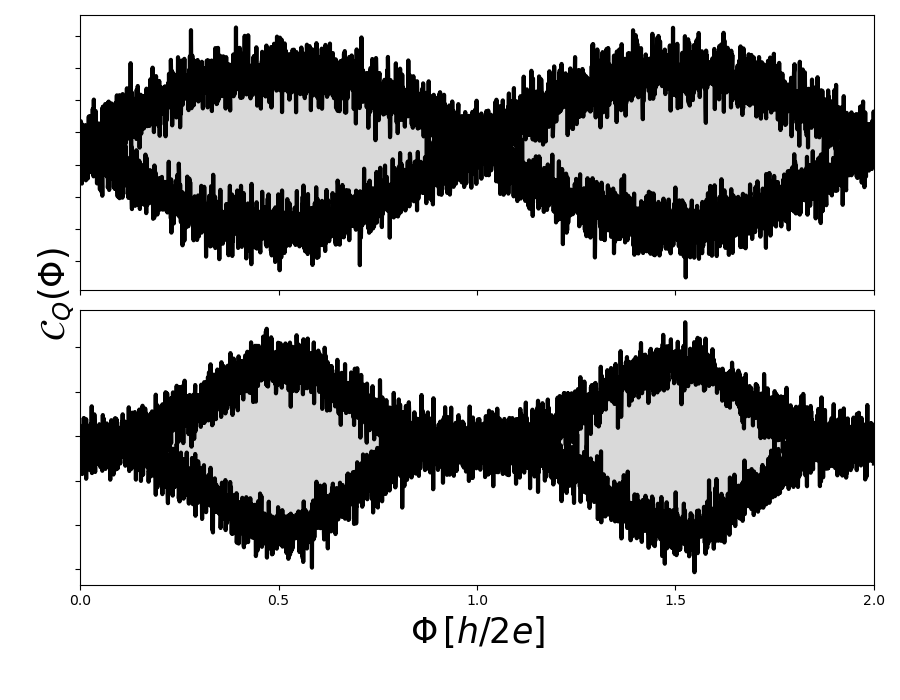

In [ ]:
Noise = lambda m, sigma: np.random.normal(m, sigma, size=phi.shape)

# --- Add noise once to each curve ---
C_even_m1_n = C_even_m1 + Noise(0.0, 9.6e-4)
C_odd_m1_n  = C_odd_m1  + Noise(0.0, 9.6e-4)

C_even_m2_n = C_even_m2 + Noise(0.0, 0.006)
C_odd_m2_n  = C_odd_m2  + Noise(0.0, 0.006)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1, ax2 = axes

# -----------------------
# TOP PANEL
# -----------------------
ax1.plot(phi, C_even_m1_n, color='black', lw=3)
ax1.plot(phi, C_odd_m1_n,  color='black',  lw=3)

ax1.fill_between(phi, C_even_m1_n, C_odd_m1_n,
                 where=(C_even_m1_n >= C_odd_m1_n),
                 interpolate=True, color='black', alpha=0.15)
ax1.fill_between(phi, C_even_m1_n, C_odd_m1_n,
                 where=(C_odd_m1_n > C_even_m1_n),
                 interpolate=True, color='black', alpha=0.15)

ax1.set_xticklabels([])
ax1.set_yticklabels([])

# -----------------------
# BOTTOM PANEL
# -----------------------
ax2.plot(phi, C_even_m2_n, color='black', lw=3)
ax2.plot(phi, C_odd_m2_n,  color='black',  lw=3)

ax2.fill_between(phi, C_even_m2_n, C_odd_m2_n,
                 where=(C_even_m2_n >= C_odd_m2_n),
                 interpolate=True, color='black', alpha=0.15)
ax2.fill_between(phi, C_even_m2_n, C_odd_m2_n,
                 where=(C_odd_m2_n > C_even_m2_n),
                 interpolate=True, color='black', alpha=0.15)

ax2.set_yticklabels([])
ax2.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax2.set_xticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])

# -----------------------
# GLOBAL LABELS
# -----------------------
fig.text(0.04, 0.58, r'$\mathcal{C}_Q(\Phi)$',
         va='center', rotation='vertical', fontsize=25)

ax2.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=25)

plt.xlim(0.0, 2.0)
plt.tight_layout(rect=[0.06, 0.05, 1, 1])
#plt.savefig("../Impedance_calc_paper/Schematic_noisy_cap.png", dpi=600)
plt.show()

/var/folders/48/y24539z12pz_600tsnssd6vr0000gn/T/ipykernel_15134/3121712191.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.06, 0.05, 1, 1])


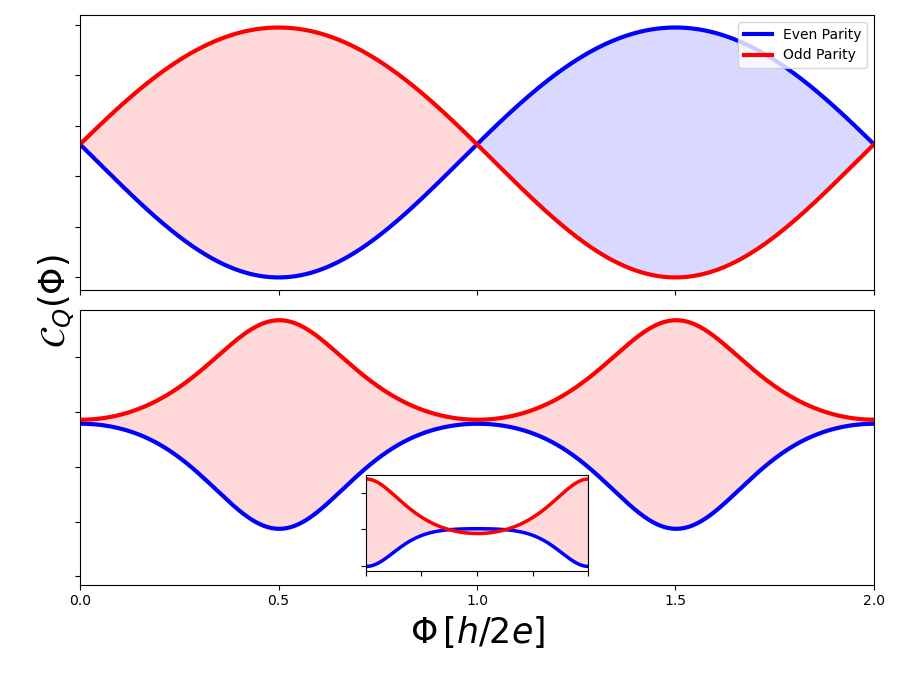

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# phi, C_odd_m1, C_even_m1, C_odd_m2, C_even_m2 assumed defined
# ALSO assumed defined for inset:
#   C_odd_m2_ndc, C_even_m2_ndc  (same shape as phi)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1, ax2 = axes

# -----------------------
# TOP PANEL
# -----------------------
ax1.plot(phi, C_even_m1, color='blue', lw=3, label='Even Parity')
ax1.plot(phi, C_odd_m1,  color='red',  lw=3, label='Odd Parity')

ax1.fill_between(phi, C_even_m1, C_odd_m1,
                 where=(C_even_m1 >= C_odd_m1),
                 interpolate=True, color='blue', alpha=0.15)
ax1.fill_between(phi, C_even_m1, C_odd_m1,
                 where=(C_odd_m1 > C_even_m1),
                 interpolate=True, color='red', alpha=0.15)

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_xlim(0.0,2.0)
ax1.legend(loc='upper right')

# -----------------------
# BOTTOM PANEL
# -----------------------
ax2.plot(phi, C_even_m2, color='blue', lw=3)
ax2.plot(phi, C_odd_m2,  color='red',  lw=3)

ax2.fill_between(phi, C_even_m2, C_odd_m2,
                 where=(C_even_m2 >= C_odd_m2),
                 interpolate=True, color='blue', alpha=0.15)
ax2.fill_between(phi, C_even_m2, C_odd_m2,
                 where=(C_odd_m2 > C_even_m2),
                 interpolate=True, color='red', alpha=0.15)

ax2.set_yticklabels([])

ax2.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax2.set_xticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])

# -----------------------
# INSET (bottom panel)
# -----------------------
# mask for 0.5 <= phi <= 1.5

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------
# INSET (bottom panel)
# -----------------------
axins = inset_axes(ax2, width="28%", height="35%",
                   loc="lower center", borderpad=1.0)

axins.plot(phi, C_even_m2_ndc, color='blue', lw=2.5)
axins.plot(phi, C_odd_m2_ndc,  color='red',  lw=2.5)

axins.fill_between(phi, C_even_m2_ndc, C_odd_m2_ndc,
                   where=(C_even_m2_ndc >= C_odd_m2_ndc),
                   interpolate=True, color='blue', alpha=0.15)
axins.fill_between(phi, C_even_m2_ndc, C_odd_m2_ndc,
                   where=(C_odd_m2_ndc > C_even_m2_ndc),
                   interpolate=True, color='red', alpha=0.15)

# Only restrict the visible x-range
axins.set_xlim(0.5, 1.5)

# Clean inset styling
axins.set_xticklabels([])
axins.set_yticklabels([])

# -----------------------
# GLOBAL LABELS
# -----------------------
fig.text(0.04, 0.57, r'$\mathcal{C}_Q(\Phi)$',
         va='center', rotation='vertical', fontsize=25)

ax2.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=25)
ax2.set_xlim(0.0,2.0)
ax2.set_ylim(-0.003, None)

plt.xlim(0.0, 2.0)
plt.tight_layout(rect=[0.06, 0.05, 1, 1])
#plt.savefig("../Impedance_calc_paper/Schematic_clean_cap.png", dpi=600)
plt.show()


In [112]:
### Topological regime in Model 1:
phi = np.linspace(0.,2.0,3000)
phi_zoom = np.linspace(0.5,1.5,3000)
global t_L, t_R, zeta_L, zeta_R, delta, delta_QD
zeta_L = complex(0.0, 0.0)
zeta_R = complex(0.0, 0.0)
delta = 0.0
delta_QD = 4.0
t_L, t_R = 0.3 , 0.3
L_odd_m1, L_even_m1 = m1_inductance(phi=phi, parity="odd"), m1_inductance(phi=phi, parity="even")
C_odd_m1, C_even_m1 = m1_capacitance(phi=phi, parity="odd"), m1_capacitance(phi=phi, parity="even")
L_max_m1 = max(np.max(L_even_m1), np.max(L_odd_m1))
C_max_m1 = max(np.max(C_even_m1), np.max(C_odd_m1))
grad_C_odd_m1, grad_C_even_m1 = np.gradient(C_odd_m1, phi), np.gradient(C_even_m1, phi)
d2C_dphi2_odd_m1, d2C_dphi2_even_m1 = np.gradient(grad_C_odd_m1, phi), np.gradient(grad_C_even_m1, phi)

### Trivial regime in Model 2:
phi_p = np.linspace(0.65,4.65,3000)
phi_p_zoom = np.linspace(1.65,3.65,3000)
global epsilon_L, epsilon_R, epsilon_D, A_L, A_R, B_L, B_R
epsilon_L = 0.49; epsilon_R = 0.33; epsilon_D = 3.2
A_L = complex(0.72, 0.46)
A_R = complex(-0.21, 1.00)
B_L = complex(0.10, 0.30)
B_R = complex(0.72, 0.53)
L_odd_m2, L_even_m2 = m2_inductance(phi=phi_p, parity="odd"), m2_inductance(phi=phi_p, parity="even")
C_odd_m2, C_even_m2 = m2_capacitance(phi=phi_p, parity="odd"), m2_capacitance(phi=phi_p, parity="even")
L_max_m2 = max(np.max(L_even_m2), np.max(L_odd_m2))
C_max_m2 = max(np.max(C_even_m2), np.max(C_odd_m2))
grad_C_odd_m2, grad_C_even_m2 = np.gradient(C_odd_m2, phi_p), np.gradient(C_even_m2, phi_p)
d2C_dphi2_odd_m2, d2C_dphi2_even_m2 = np.gradient(grad_C_odd_m2, phi_p), np.gradient(grad_C_even_m2, phi_p)

### Narrow double crossing
phi_ndc = np.linspace(0.65,4.65,3000)
phi_ndc_zoom = np.linspace(1.65,3.65,3000)
epsilon_L = 0.49; epsilon_R = 0.33; epsilon_D = 2.5
A_L = complex(0.72, 0.46)
A_R = complex(-0.21, 1.00)
B_L = complex(0.10, 0.30)
B_R = complex(0.72, 0.53)
L_odd_m2_ndc, L_even_m2_ndc = m2_inductance(phi=phi_ndc_zoom, parity="odd"), m2_inductance(phi=phi_ndc_zoom, parity="even")
C_odd_m2_ndc, C_even_m2_ndc = m2_capacitance(phi=phi_ndc_zoom, parity="odd"), m2_capacitance(phi=phi_ndc_zoom, parity="even")
L_max_m2_ndc = max(np.max(L_even_m2_ndc), np.max(L_odd_m2_ndc))
C_max_m2_ndc = max(np.max(C_even_m2_ndc), np.max(C_odd_m2_ndc))
grad_C_odd_m2_ndc, grad_C_even_m2_ndc = np.gradient(C_odd_m2_ndc, phi_ndc_zoom), np.gradient(C_even_m2_ndc, phi_ndc_zoom)
d2C_dphi2_odd_ndc, d2C_dphi2_even_ndc = np.gradient(grad_C_odd_m2_ndc, phi_ndc_zoom), np.gradient(grad_C_even_m2_ndc, phi_ndc_zoom)

/var/folders/48/y24539z12pz_600tsnssd6vr0000gn/T/ipykernel_15134/1252533396.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.06, 0.05, 1, 1])


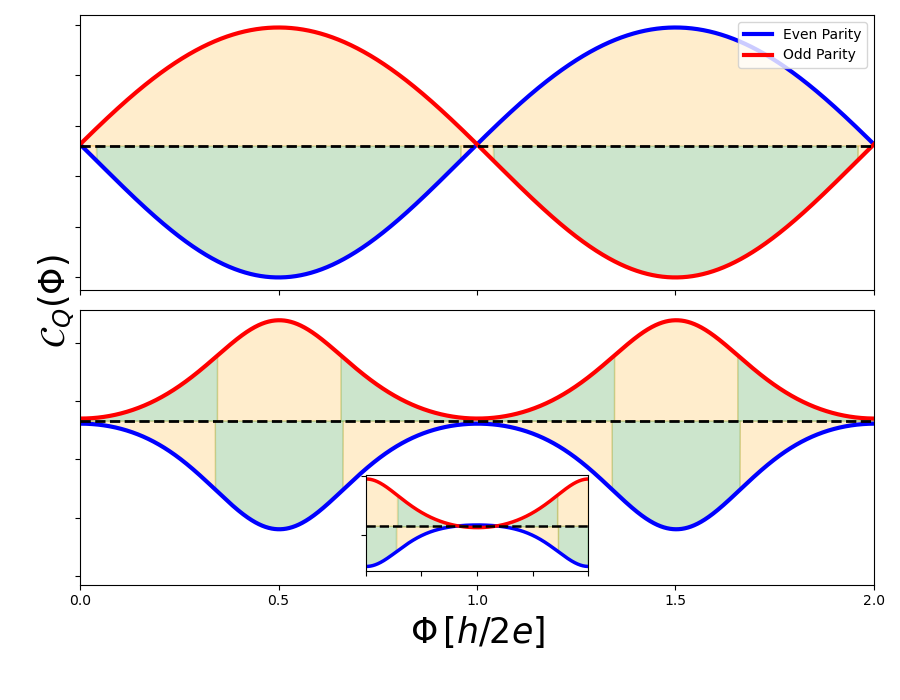

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# phi, C_odd_m1, C_even_m1, C_odd_m2, C_even_m2 assumed defined
# ALSO assumed defined for inset:
#   C_odd_m2_ndc, C_even_m2_ndc  (same shape as phi)

# Curvature arrays ONLY used to decide fill sign/color:
# d2C_dphi2_odd_m1,  d2C_dphi2_even_m1
# d2C_dphi2_odd_m2,  d2C_dphi2_even_m2
# d2C_dphi2_odd_ndc, d2C_dphi2_even_ndc

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1, ax2 = axes

COL_POS = "green"
COL_NEG = "orange"

# -----------------------
# TOP PANEL
# Center line: mean of ONE capacitance curve (use even by default)
# -----------------------
center1 = np.mean(C_even_m1) + 0.0001

ax1.plot(phi, C_even_m1, color='blue', lw=3, label='Even Parity')
ax1.plot(phi, C_odd_m1,  color='red',  lw=3, label='Odd Parity')

ax1.axhline(center1, color='k', ls='--', lw=2)

# Fill between curve and center line; color set by curvature sign
ax1.fill_between(phi, center1, C_even_m1,
                 where=(d2C_dphi2_even_m1 >= 0),
                 interpolate=True, color=COL_POS, alpha=0.20)
ax1.fill_between(phi, center1, C_even_m1,
                 where=(d2C_dphi2_even_m1 < 0),
                 interpolate=True, color=COL_NEG, alpha=0.20)

ax1.fill_between(phi, center1, C_odd_m1,
                 where=(d2C_dphi2_odd_m1 >= 0),
                 interpolate=True, color=COL_POS, alpha=0.20)
ax1.fill_between(phi, center1, C_odd_m1,
                 where=(d2C_dphi2_odd_m1 < 0),
                 interpolate=True, color=COL_NEG, alpha=0.20)

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_xlim(0.0, 2.0)
ax1.legend(loc='upper right')

# -----------------------
# BOTTOM PANEL
# Center line: avg(min of odd C, max of even C)
# -----------------------
center2 = 0.5 * (np.min(C_odd_m2) + np.max(C_even_m2))

ax2.plot(phi, C_even_m2, color='blue', lw=3)
ax2.plot(phi, C_odd_m2,  color='red',  lw=3)

ax2.axhline(center2, color='k', ls='--', lw=2)

ax2.fill_between(phi, center2, C_even_m2,
                 where=(d2C_dphi2_even_m2 >= 0),
                 interpolate=True, color=COL_POS, alpha=0.20)
ax2.fill_between(phi, center2, C_even_m2,
                 where=(d2C_dphi2_even_m2 < 0),
                 interpolate=True, color=COL_NEG, alpha=0.20)

ax2.fill_between(phi, center2, C_odd_m2,
                 where=(d2C_dphi2_odd_m2 >= 0),
                 interpolate=True, color=COL_POS, alpha=0.20)
ax2.fill_between(phi, center2, C_odd_m2,
                 where=(d2C_dphi2_odd_m2 < 0),
                 interpolate=True, color=COL_NEG, alpha=0.20)

ax2.set_yticklabels([])

ax2.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax2.set_xticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])

# -----------------------
# INSET (bottom panel)
# Center line: avg(min of odd C, max of even C) using NDC capacitance arrays
# -----------------------
axins = inset_axes(ax2, width="28%", height="35%",
                   loc="lower center", borderpad=1.0)

center_ins = 0.5 * (np.min(C_odd_m2_ndc) + np.max(C_even_m2_ndc))

axins.plot(phi, C_even_m2_ndc, color='blue', lw=2.5)
axins.plot(phi, C_odd_m2_ndc,  color='red',  lw=2.5)

axins.axhline(center_ins, color='k', ls='--', lw=1.8)

axins.fill_between(phi, center_ins, C_even_m2_ndc,
                   where=(d2C_dphi2_even_ndc >= 0),
                   interpolate=True, color=COL_POS, alpha=0.20)
axins.fill_between(phi, center_ins, C_even_m2_ndc,
                   where=(d2C_dphi2_even_ndc < 0),
                   interpolate=True, color=COL_NEG, alpha=0.20)

axins.fill_between(phi, center_ins, C_odd_m2_ndc,
                   where=(d2C_dphi2_odd_ndc >= 0),
                   interpolate=True, color=COL_POS, alpha=0.20)
axins.fill_between(phi, center_ins, C_odd_m2_ndc,
                   where=(d2C_dphi2_odd_ndc < 0),
                   interpolate=True, color=COL_NEG, alpha=0.20)

axins.set_xlim(0.5, 1.5)
axins.set_xticklabels([])
axins.set_yticklabels([])

# -----------------------
# GLOBAL LABELS
# -----------------------
fig.text(0.04, 0.57, r'$\mathcal{C}_Q(\Phi)$',
         va='center', rotation='vertical', fontsize=25)

ax2.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=25)
ax2.set_xlim(0.0, 2.0)
ax2.set_ylim(-0.003, None)

plt.xlim(0.0, 2.0)
plt.tight_layout(rect=[0.06, 0.05, 1, 1])
#plt.savefig("../Impedance_calc_paper/Schematic_clean_cap.png", dpi=600)
plt.show()


/var/folders/48/y24539z12pz_600tsnssd6vr0000gn/T/ipykernel_15134/1303023250.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.06, 0.05, 1, 1])


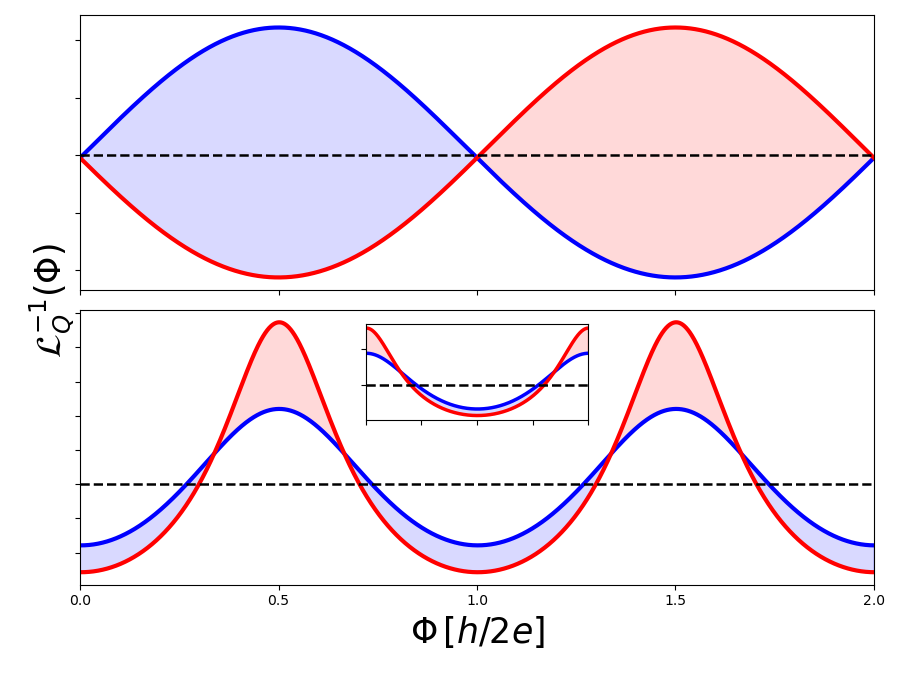

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# phi assumed defined
# Inductance arrays assumed defined:
#   L_odd_m1, L_even_m1
#   L_odd_m2, L_even_m2
#   L_odd_m2_ndc, L_even_m2_ndc  (same shape as phi)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1, ax2 = axes

# -----------------------
# TOP PANEL
# -----------------------
ax1.plot(phi, L_even_m1, color='blue', lw=3, label='Even Parity')
ax1.plot(phi, L_odd_m1,  color='red',  lw=3, label='Odd Parity')

ax1.fill_between(phi, L_even_m1, L_odd_m1,
                 where=(L_even_m1 >= L_odd_m1),
                 interpolate=True, color='blue', alpha=0.15)
ax1.fill_between(phi, L_even_m1, L_odd_m1,
                 where=(L_odd_m1 > L_even_m1),
                 interpolate=True, color='red', alpha=0.15)

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_xlim(0.0, 2.0)
ax1.hlines(0.0, xmin=0.0, xmax=2.0, color='k', ls='--', lw=1.8)

# -----------------------
# BOTTOM PANEL
# -----------------------
ax2.plot(phi, L_even_m2, color='blue', lw=3)
ax2.plot(phi, L_odd_m2,  color='red',  lw=3)

ax2.fill_between(phi, L_even_m2, L_odd_m2,
                 where=(L_even_m2 >= L_odd_m2),
                 interpolate=True, color='blue', alpha=0.15)
ax2.fill_between(phi, L_even_m2, L_odd_m2,
                 where=(L_odd_m2 > L_even_m2),
                 interpolate=True, color='red', alpha=0.15)

ax2.set_yticklabels([])

ax2.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax2.set_xticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])
ax2.hlines(0.0, xmin=0.0, xmax=2.0, color='k', ls='--', lw=1.8)

# -----------------------
# INSET (bottom panel)
# -----------------------
axins = inset_axes(ax2, width="28%", height="35%",
                   loc="upper center", borderpad=1.0)

axins.plot(phi, L_even_m2_ndc, color='blue', lw=2.5)
axins.plot(phi, L_odd_m2_ndc,  color='red',  lw=2.5)

axins.fill_between(phi, L_even_m2_ndc, L_odd_m2_ndc,
                   where=(L_even_m2_ndc >= L_odd_m2_ndc),
                   interpolate=True, color='blue', alpha=0.15)
axins.fill_between(phi, L_even_m2_ndc, L_odd_m2_ndc,
                   where=(L_odd_m2_ndc > L_even_m2_ndc),
                   interpolate=True, color='red', alpha=0.15)

axins.hlines(0.0, xmin=0.0, xmax=2.0, color='k', ls='--', lw=1.8)
axins.set_xticklabels([])
axins.set_yticklabels([])

# -----------------------
# GLOBAL LABELS
# -----------------------
fig.text(0.03, 0.57, r'$\mathcal{L}_Q^{-1}(\Phi)$',
         va='center', rotation='vertical', fontsize=25)

ax2.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=25)
ax2.set_xlim(0.0, 2.0)

plt.xlim(0.0, 2.0)
plt.tight_layout(rect=[0.06, 0.05, 1, 1])
#plt.savefig("../Impedance_calc_paper/Schematic_clean_ind.png", dpi=600)
plt.show()


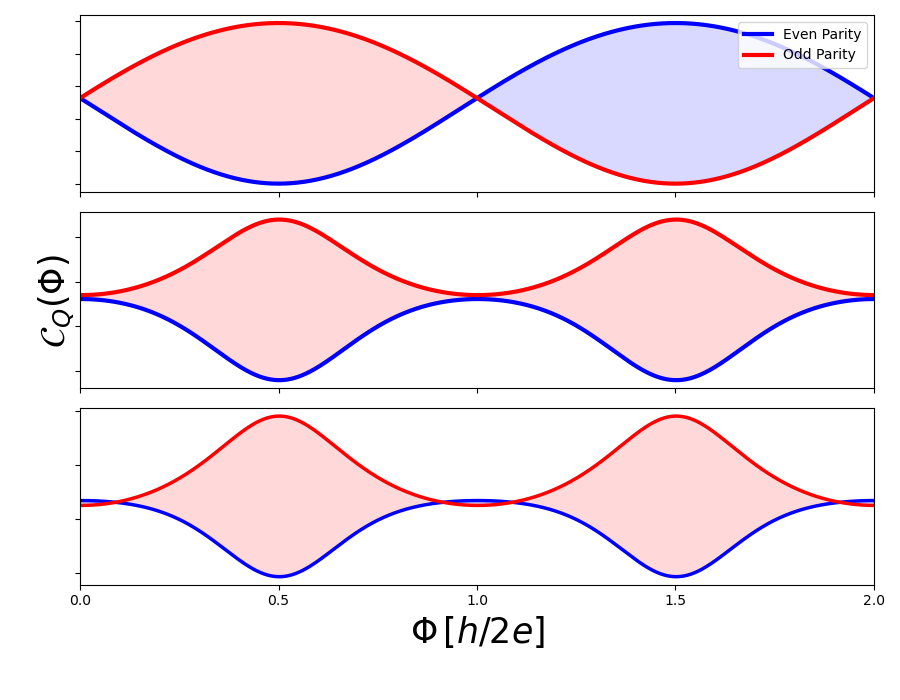

In [102]:
# phi, C_odd_m1, C_even_m1, C_odd_m2, C_even_m2 assumed defined
# ALSO assumed defined for inset/3rd row:
#   C_odd_m2_ndc, C_even_m2_ndc  (same shape as phi)

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
ax1, ax2, ax3 = axes

# -----------------------
# TOP PANEL
# -----------------------
ax1.plot(phi, C_even_m1, color='blue', lw=3, label='Even Parity')
ax1.plot(phi, C_odd_m1,  color='red',  lw=3, label='Odd Parity')

ax1.fill_between(phi, C_even_m1, C_odd_m1,
                 where=(C_even_m1 >= C_odd_m1),
                 interpolate=True, color='blue', alpha=0.15)
ax1.fill_between(phi, C_even_m1, C_odd_m1,
                 where=(C_odd_m1 > C_even_m1),
                 interpolate=True, color='red', alpha=0.15)

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_xlim(0.0,2.0)
ax1.legend(loc='upper right')

# -----------------------
# MIDDLE PANEL (was bottom)
# -----------------------
ax2.plot(phi, C_even_m2, color='blue', lw=3)
ax2.plot(phi, C_odd_m2,  color='red',  lw=3)

ax2.fill_between(phi, C_even_m2, C_odd_m2,
                 where=(C_even_m2 >= C_odd_m2),
                 interpolate=True, color='blue', alpha=0.15)
ax2.fill_between(phi, C_even_m2, C_odd_m2,
                 where=(C_odd_m2 > C_even_m2),
                 interpolate=True, color='red', alpha=0.15)

ax2.set_yticklabels([])
ax2.set_xticklabels([])   # no x tick labels on middle

# -----------------------
# BOTTOM PANEL (was inset)
# -----------------------
ax3.plot(phi, C_even_m2_ndc, color='blue', lw=2.5)
ax3.plot(phi, C_odd_m2_ndc,  color='red',  lw=2.5)

ax3.fill_between(phi, C_even_m2_ndc, C_odd_m2_ndc,
                 where=(C_even_m2_ndc >= C_odd_m2_ndc),
                 interpolate=True, color='blue', alpha=0.15)
ax3.fill_between(phi, C_even_m2_ndc, C_odd_m2_ndc,
                 where=(C_odd_m2_ndc > C_even_m2_ndc),
                 interpolate=True, color='red', alpha=0.15)

ax3.set_xlim(0.5, 1.5)
ax3.set_yticklabels([])

ax3.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax3.set_xticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])

# -----------------------
# GLOBAL LABELS
# -----------------------
fig.text(0.04, 0.57, r'$\mathcal{C}_Q(\Phi)$',
         va='center', rotation='vertical', fontsize=25)

ax3.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=25)
ax3.set_xlim(0.0,2.0)

plt.xlim(0.0, 2.0)
plt.tight_layout(rect=[0.06, 0.05, 1, 1])
#plt.savefig("../Impedance_calc_paper/Schematic_clean_cap.png", dpi=600)
plt.show()


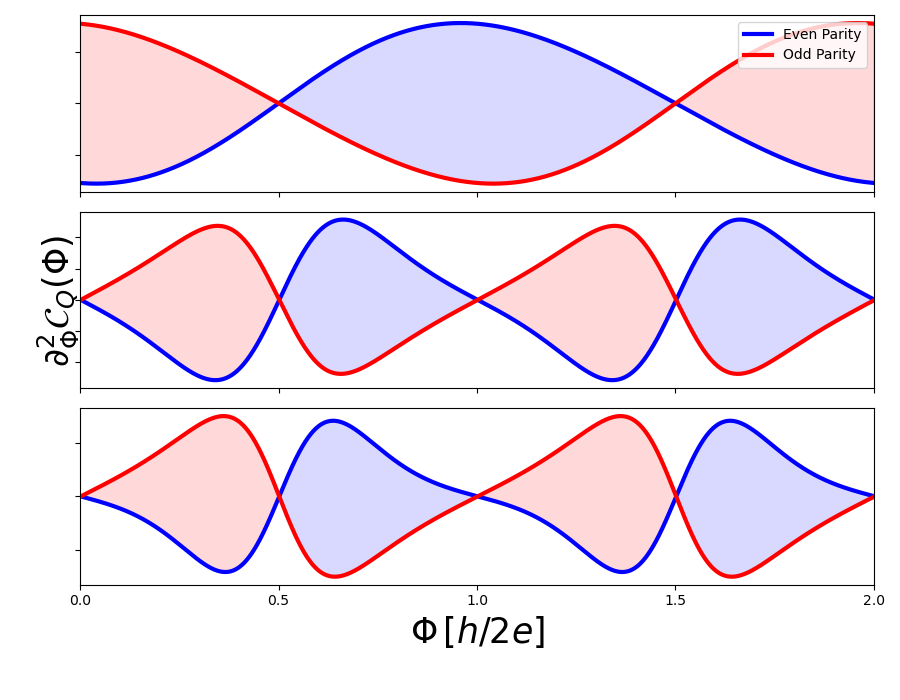

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# phi assumed defined
# Arrays assumed defined:
# d2C_dphi2_odd_m1, d2C_dphi2_even_m1
# d2C_dphi2_odd_m2, d2C_dphi2_even_m2
# d2C_dphi2_ndc, d2C_dphi2_even_ndc

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
ax1, ax2, ax3 = axes

# -----------------------
# TOP PANEL
# -----------------------
ax1.plot(phi, d2C_dphi2_even_m1, color='blue', lw=3, label='Even Parity')
ax1.plot(phi, d2C_dphi2_odd_m1,  color='red',  lw=3, label='Odd Parity')

ax1.fill_between(phi, d2C_dphi2_even_m1, d2C_dphi2_odd_m1,
                 where=(d2C_dphi2_even_m1 >= d2C_dphi2_odd_m1),
                 interpolate=True, color='blue', alpha=0.15)
ax1.fill_between(phi, d2C_dphi2_even_m1, d2C_dphi2_odd_m1,
                 where=(d2C_dphi2_odd_m1 > d2C_dphi2_even_m1),
                 interpolate=True, color='red', alpha=0.15)

ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_xlim(0.0, 2.0)
ax1.legend(loc='upper right')

# -----------------------
# MIDDLE PANEL
# -----------------------
ax2.plot(phi, d2C_dphi2_even_m2, color='blue', lw=3)
ax2.plot(phi, d2C_dphi2_odd_m2,  color='red',  lw=3)

ax2.fill_between(phi, d2C_dphi2_even_m2, d2C_dphi2_odd_m2,
                 where=(d2C_dphi2_even_m2 >= d2C_dphi2_odd_m2),
                 interpolate=True, color='blue', alpha=0.15)
ax2.fill_between(phi, d2C_dphi2_even_m2, d2C_dphi2_odd_m2,
                 where=(d2C_dphi2_odd_m2 > d2C_dphi2_even_m2),
                 interpolate=True, color='red', alpha=0.15)

ax2.set_yticklabels([])
ax2.set_xticklabels([])

# -----------------------
# BOTTOM PANEL
# -----------------------
ax3.plot(phi, d2C_dphi2_even_ndc, color='blue', lw=3)
ax3.plot(phi, d2C_dphi2_odd_ndc,  color='red',  lw=3)

ax3.fill_between(phi, d2C_dphi2_even_ndc, d2C_dphi2_odd_ndc,
                 where=(d2C_dphi2_even_ndc >= d2C_dphi2_odd_ndc),
                 interpolate=True, color='blue', alpha=0.15)
ax3.fill_between(phi, d2C_dphi2_even_ndc, d2C_dphi2_odd_ndc,
                 where=(d2C_dphi2_odd_ndc > d2C_dphi2_even_ndc),
                 interpolate=True, color='red', alpha=0.15)

ax3.set_xlim(0.5, 1.5)
ax3.set_yticklabels([])

ax3.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax3.set_xticklabels(['0.0', '0.5', '1.0', '1.5', '2.0'])

# -----------------------
# GLOBAL LABELS
# -----------------------
fig.text(0.04, 0.57, r'$\partial_\Phi^2 \mathcal{C}_Q(\Phi)$',
         va='center', rotation='vertical', fontsize=25)

ax3.set_xlabel(r'$\Phi\,[h/2e]$', fontsize=25)
ax3.set_xlim(0.0, 2.0)

plt.xlim(0.0, 2.0)
plt.tight_layout(rect=[0.06, 0.05, 1, 1])
plt.show()
